Note: you may need to restart the kernel to use updated packages.
Environment ready.
Total load functions: 25

load_combine
load_contracts
load_depth_charts
load_draft_picks
load_ff_opportunity
load_ff_playerids
load_ff_rankings
load_ffverse
load_ftn_charting
load_injuries
load_nextgen_stats
load_officials
load_participation
load_pbp
load_pfr_advstats
load_player_stats
load_players
load_rosters
load_rosters_weekly
load_schedules
load_snap_counts
load_stats
load_team_stats
load_teams
load_trades
Help on function load_player_stats in module nflreadpy.load_stats:

load_player_stats(
    seasons: int | list[int] | bool | None = None,
    summary_level: Literal['week', 'reg', 'post', 'reg+post'] = 'week'
) -> polars.dataframe.frame.DataFrame
    Load NFL player statistics.

    Args:
        seasons: Season(s) to load. If None, loads current season.
                If True, loads all available data.
                If int or list of ints, loads specified season(s).
        summary_level: Su

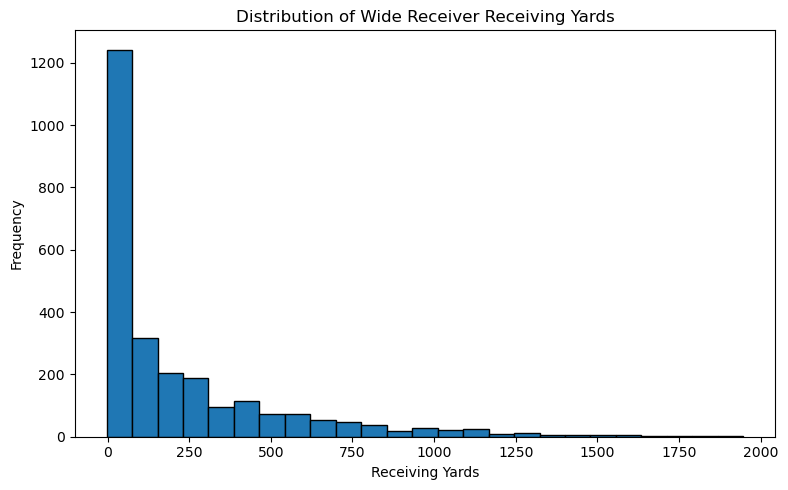

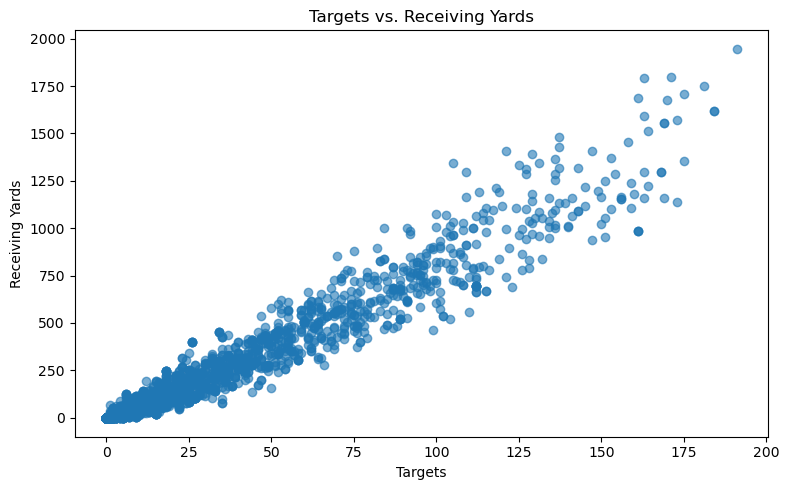

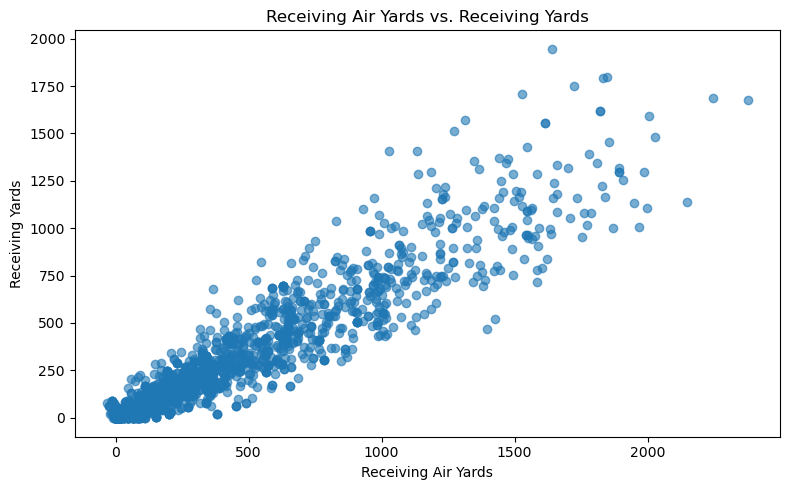

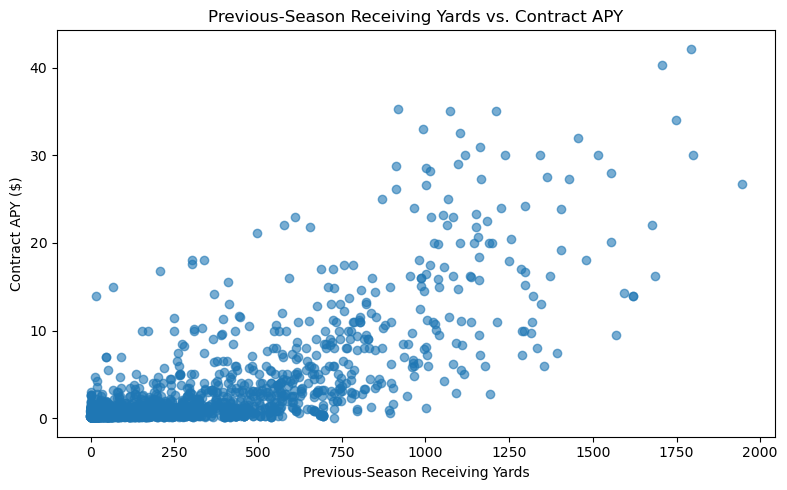

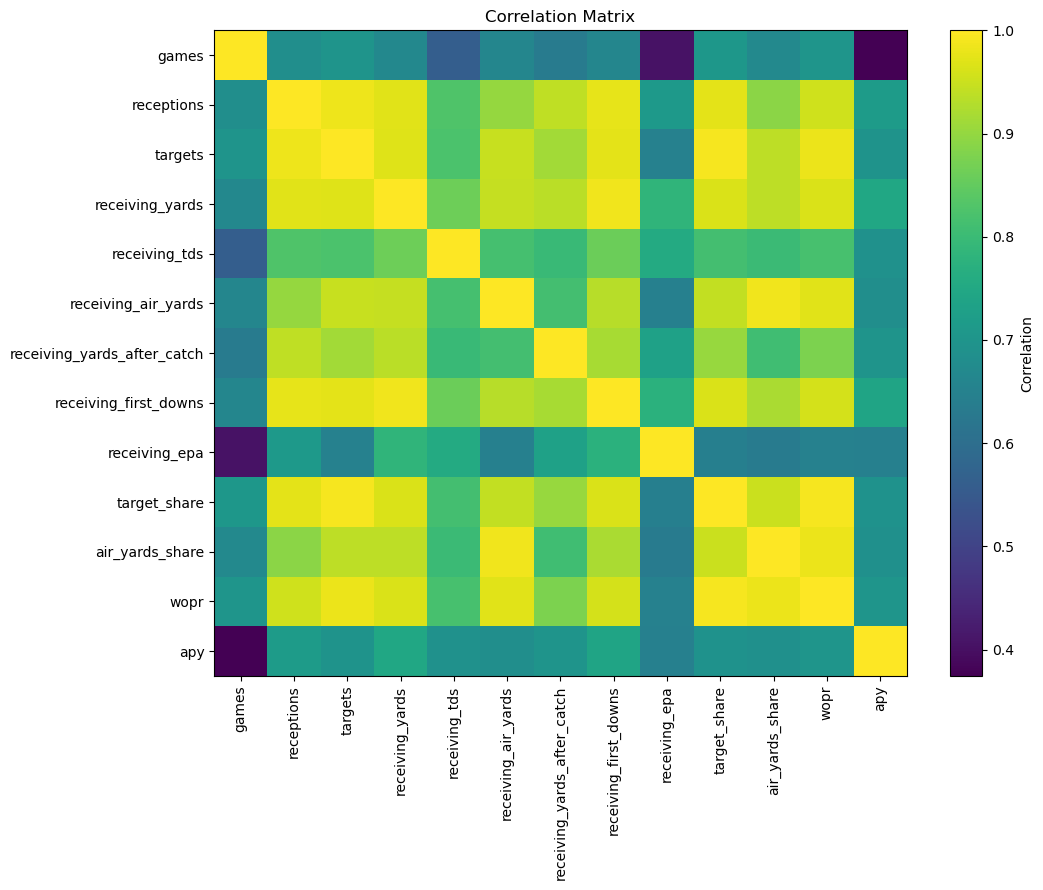

R-squared: 0.99
RMSE: 28.99
MAE: 18.16


In [1]:
from pathlib import Path

notebook_path = Path.home() / "Desktop" / "03_EDA.ipynb"

%run "$notebook_path"

## Preprocessing and Feature Engineering

After observing the characteristics of many of our variables it is time to move forward with what we determine best for each variable as some will be helpful as they are, some need some manipulation and others will not be helpful in our analysis

In [2]:
# Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LassoCV
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [3]:
# Create a working copy of the EDA dataset

preprocessing_df = eda_df.copy()

print("Original dataset shape:", preprocessing_df.shape)

Original dataset shape: (2590, 57)


In [4]:
# Define the target variable

target_variable = "receiving_yards"

print("Target variable:", target_variable)

Target variable: receiving_yards


In [5]:
# Remove variables that should not be predictors

fantasy_variables = [
    "fantasy_points",
    "fantasy_points_ppr"
]

contract_variables = [
    "team",
    "is_active",
    "year_signed",
    "years",
    "value",
    "apy",
    "guaranteed",
    "apy_cap_pct",
    "inflated_value",
    "inflated_apy",
    "inflated_guaranteed"
]

identifier_variables = [
    "player",
    "gsis_id",
    "position",
    "college",
    "draft_team",
    "recent_team",
    "date_of_birth"
]

variables_to_remove = (
    fantasy_variables +
    contract_variables +
    identifier_variables
)

variables_to_remove = [
    column
    for column in variables_to_remove
    if column in preprocessing_df.columns
]

preprocessing_df = preprocessing_df.drop(
    columns=variables_to_remove
)

print("Variables removed:")

for column in variables_to_remove:
    print(column)

Variables removed:
fantasy_points
fantasy_points_ppr
team
is_active
year_signed
years
value
apy
guaranteed
apy_cap_pct
inflated_value
inflated_apy
inflated_guaranteed
player
gsis_id
position
college
draft_team
recent_team


In [6]:
# Remove variables with substantial missingness

missing_variables = [
    "racr",
    "receiving_epa"
]

missing_variables = [
    column
    for column in missing_variables
    if column in preprocessing_df.columns
]

preprocessing_df = preprocessing_df.drop(
    columns=missing_variables
)

print("Variables removed because of missingness:")

for column in missing_variables:
    print(column)

Variables removed because of missingness:
racr
receiving_epa


In [7]:
# Setting up a function for safe mathematical division

def safe_divide(numerator, denominator):

    return np.where(
        denominator > 0,
        numerator / denominator,
        0
    )

In [ ]:
# Create opportunity variables, these are the number of targets, receptions, air yards, first downs, and touchdowns per game
# Aggregations and mathematical functions to engineer new features

preprocessing_df["targets_per_game"] = safe_divide(
    preprocessing_df["targets"],
    preprocessing_df["games"]
)

preprocessing_df["receptions_per_game"] = safe_divide(
    preprocessing_df["receptions"],
    preprocessing_df["games"]
)

preprocessing_df["air_yards_per_game"] = safe_divide(
    preprocessing_df["receiving_air_yards"],
    preprocessing_df["games"]
)

preprocessing_df["first_downs_per_game"] = safe_divide(
    preprocessing_df["receiving_first_downs"],
    preprocessing_df["games"]
)

preprocessing_df["touchdowns_per_game"] = safe_divide(
    preprocessing_df["receiving_tds"],
    preprocessing_df["games"]
)

In [9]:
# Create efficiency variables

preprocessing_df["catch_rate"] = safe_divide(
    preprocessing_df["receptions"],
    preprocessing_df["targets"]
)

preprocessing_df["air_yards_per_target"] = safe_divide(
    preprocessing_df["receiving_air_yards"],
    preprocessing_df["targets"]
)

preprocessing_df["yac_per_reception"] = safe_divide(
    preprocessing_df["receiving_yards_after_catch"],
    preprocessing_df["receptions"]
)

preprocessing_df["first_down_rate"] = safe_divide(
    preprocessing_df["receiving_first_downs"],
    preprocessing_df["targets"]
)

preprocessing_df["touchdown_rate"] = safe_divide(
    preprocessing_df["receiving_tds"],
    preprocessing_df["targets"]
)

In [10]:
# Replace infinite values

preprocessing_df = preprocessing_df.replace(
    [np.inf, -np.inf],
    np.nan
)

In [11]:
# Summary statistics for engineered variables

engineered_variables = [
    "targets_per_game",
    "receptions_per_game",
    "air_yards_per_game",
    "first_downs_per_game",
    "touchdowns_per_game",
    "catch_rate",
    "air_yards_per_target",
    "yac_per_reception",
    "first_down_rate",
    "touchdown_rate"
]

engineered_variables = [
    column
    for column in engineered_variables
    if column in preprocessing_df.columns
]

preprocessing_df[
    engineered_variables
].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
targets_per_game,2590.0,2.703,2.412,0.0,1.000,2.000,4.000,11.500
receptions_per_game,2590.0,1.592,1.555,0.0,0.462,1.067,2.267,8.529
air_yards_per_game,2590.0,29.500,28.207,-5.5,7.446,20.919,44.733,152.333
first_downs_per_game,2590.0,0.957,1.001,0.0,0.167,0.667,1.400,5.250
touchdowns_per_game,2590.0,0.112,0.183,0.0,0.000,0.000,0.176,2.000
catch_rate,2590.0,0.522,0.273,0.0,0.400,0.571,0.680,1.000
air_yards_per_target,2590.0,9.732,6.413,-9.0,6.423,9.762,12.792,50.000
yac_per_reception,2590.0,3.489,2.994,0.0,1.571,3.302,4.829,71.000
first_down_rate,2590.0,0.298,0.209,0.0,0.167,0.333,0.421,1.000
touchdown_rate,2590.0,0.032,0.068,0.0,0.000,0.000,0.048,1.000


In [12]:
# Select candidate predictors

candidate_predictors = [

    "games",

    "targets_per_game",
    "target_share",

    "catch_rate",

    "air_yards_per_target",
    "air_yards_share",

    "yac_per_reception",

    "touchdowns_per_game",
    "first_down_rate",

    "years_of_experience"

]

candidate_predictors = [
    column
    for column in candidate_predictors
    if column in preprocessing_df.columns
]

print("Candidate predictors:")

for column in candidate_predictors:
    print(column)

Candidate predictors:
games
targets_per_game
target_share
catch_rate
air_yards_per_target
air_yards_share
yac_per_reception
touchdowns_per_game
first_down_rate
years_of_experience


In [ ]:
# Correlation matrix after feature reduction

reduced_correlation_matrix = (
    preprocessing_df[
        candidate_predictors +
        [target_variable]
    ]
    .corr()
)

display(
    reduced_correlation_matrix.round(3)
)

,games,targets_per_game,target_share,catch_rate,air_yards_per_target,air_yards_share,yac_per_reception,touchdowns_per_game,first_down_rate,years_of_experience,receiving_yards
games,1.000,0.485,0.705,0.315,0.110,0.669,0.259,0.362,0.266,0.534,0.667
targets_per_game,0.485,1.000,0.881,0.275,0.207,0.840,0.186,0.647,0.303,0.482,0.857
target_share,0.705,0.881,1.000,0.254,0.129,0.949,0.179,0.614,0.269,0.543,0.963
catch_rate,0.315,0.275,0.254,1.000,0.002,0.195,0.421,0.239,0.646,0.183,0.269
air_yards_per_target,0.110,0.207,0.129,0.002,1.000,0.251,0.063,0.156,0.249,0.080,0.142
air_yards_share,0.669,0.840,0.949,0.195,0.251,1.000,0.152,0.612,0.270,0.508,0.937
yac_per_reception,0.259,0.186,0.179,0.421,0.063,0.152,1.000,0.195,0.357,0.133,0.203
touchdowns_per_game,0.362,0.647,0.614,0.239,0.156,0.612,0.195,1.000,0.330,0.337,0.661
first_down_rate,0.266,0.303,0.269,0.646,0.249,0.270,0.357,0.330,1.000,0.153,0.311
years_of_experience,0.534,0.482,0.543,0.183,0.080,0.508,0.133,0.337,0.153,1.000,0.525


This now provides us a much better and wider range of working variables that are not too correlated. This will improve the accuracy and efficiency of our modeling/predicting

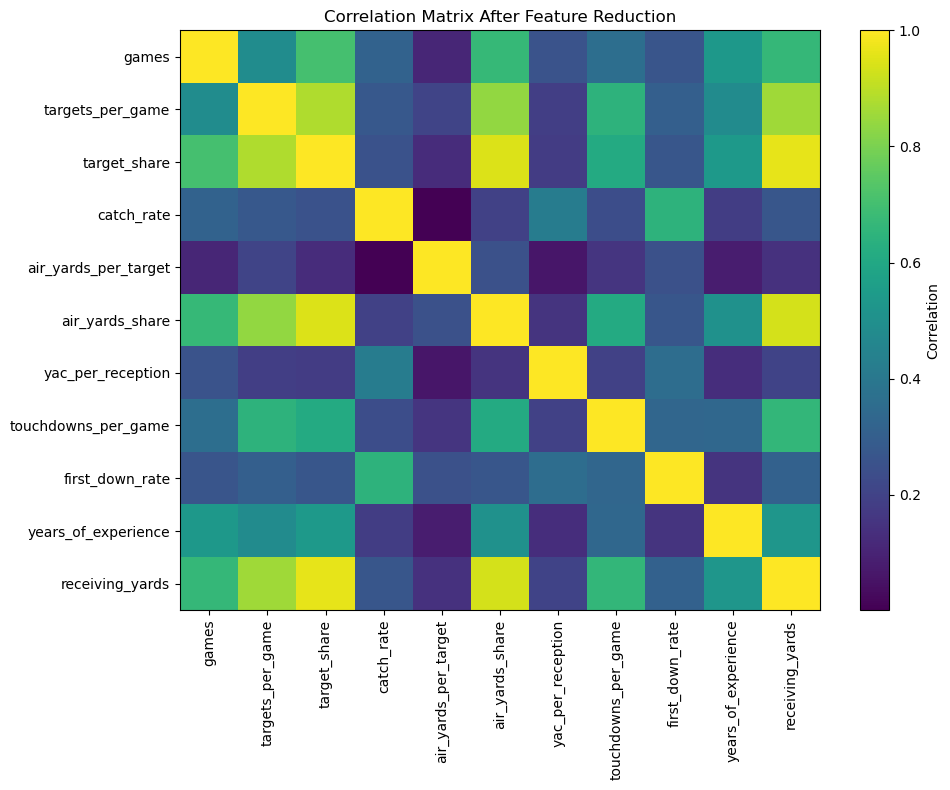

In [14]:
# Correlation heat map

plt.figure(figsize=(10,8))

plt.imshow(
    reduced_correlation_matrix,
    aspect="auto",
    interpolation="nearest"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(reduced_correlation_matrix.columns)),
    reduced_correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(reduced_correlation_matrix.columns)),
    reduced_correlation_matrix.columns
)

plt.title(
    "Correlation Matrix After Feature Reduction"
)

plt.tight_layout()

plt.show()

In [15]:
# Identify remaining highly correlated predictors

remaining_high_correlations = []

predictor_correlation_matrix = (
    preprocessing_df[candidate_predictors]
    .corr()
)

for i in range(
    len(predictor_correlation_matrix.columns)
):

    for j in range(i):

        correlation = (
            predictor_correlation_matrix.iloc[i,j]
        )

        if abs(correlation) >= .80:

            remaining_high_correlations.append([

                predictor_correlation_matrix.columns[i],

                predictor_correlation_matrix.columns[j],

                correlation

            ])

remaining_high_correlation_df = pd.DataFrame(

    remaining_high_correlations,

    columns=[

        "Variable 1",

        "Variable 2",

        "Correlation"

    ]

)

display(

    remaining_high_correlation_df

    .sort_values(

        "Correlation",

        key=abs,

        ascending=False

    )

    .round(3)

)

,Variable 1,Variable 2,Correlation
2,air_yards_share,target_share,0.949
0,target_share,targets_per_game,0.881
1,air_yards_share,targets_per_game,0.840


In [16]:
# Create the modeling dataset

modeling_columns = (
    candidate_predictors +
    [target_variable]
)

receiving_model_df = (
    preprocessing_df[
        modeling_columns
    ]
    .copy()
)

receiving_model_df = (
    receiving_model_df
    .dropna(
        subset=[target_variable]
    )
)

print(
    "Modeling dataset shape:",
    receiving_model_df.shape
)

Modeling dataset shape: (2590, 11)


In [17]:
# Split into training and testing sets

X = receiving_model_df[
    candidate_predictors
]

y = receiving_model_df[
    target_variable
]

X_train, X_test, y_train, y_test = (

    train_test_split(

        X,

        y,

        test_size=.20,

        random_state=6311

    )

)

print("Training observations:",X_train.shape[0])

print("Testing observations:",X_test.shape[0])

Training observations: 2072
Testing observations: 518


In [19]:
# Build preprocessing pipeline

numeric_preprocessor = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),

        (
            "scaler",
            StandardScaler()
        )

    ]

)

X_train_scaled = (
    numeric_preprocessor
    .fit_transform(X_train)
)

X_test_scaled = (
    numeric_preprocessor
    .transform(X_test)
)

In [20]:
# Principal Components Analysis

pca = PCA()

X_train_pca_all = pca.fit_transform(
    X_train_scaled
)

cumulative_variance = np.cumsum(
    pca.explained_variance_ratio_
)

pca_summary = pd.DataFrame({
    "Principal Component":
    np.arange(
        1,
        len(
            pca.explained_variance_ratio_
        ) + 1
    ),
    "Explained Variance":
    pca.explained_variance_ratio_,
    "Cumulative Variance":
    cumulative_variance
})

display(
    pca_summary.round(4)
)

,Principal Component,Explained Variance,Cumulative Variance
0,1,0.4590,0.4590
1,2,0.1589,0.6179
2,3,0.1048,0.7227
3,4,0.0764,0.7991
4,5,0.0675,0.8666
5,6,0.0509,0.9175
6,7,0.0374,0.9548
7,8,0.0308,0.9856
8,9,0.0112,0.9969
9,10,0.0031,1.0000


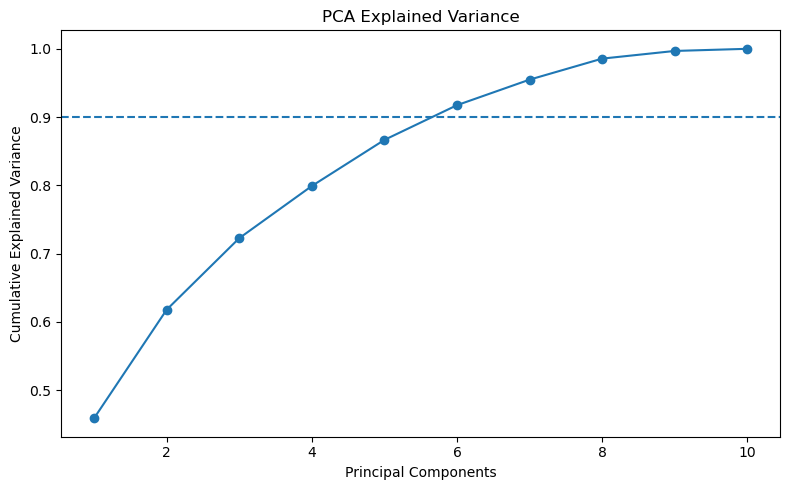

In [21]:
# PCA cumulative explained variance

plt.figure(figsize=(8,5))

plt.plot(
    pca_summary["Principal Component"],
    pca_summary["Cumulative Variance"],
    marker="o"
)

plt.axhline(
    y=.90,
    linestyle="--"
)

plt.xlabel(
    "Principal Components"
)

plt.ylabel(
    "Cumulative Explained Variance"
)

plt.title(
    "PCA Explained Variance"
)

plt.tight_layout()

plt.show()

In [22]:
# PCA loadings

n_components_90 = (
    np.argmax(
        cumulative_variance >= .90
    ) + 1
)

pca_90 = PCA(
    n_components=n_components_90
)

pca_90.fit(
    X_train_scaled
)

pca_loadings = pd.DataFrame(

    pca_90.components_.T,

    index=candidate_predictors,

    columns=[

        f"PC{i+1}"

        for i in range(
            n_components_90
        )

    ]

)

display(
    pca_loadings.round(3)
)

,PC1,PC2,PC3,PC4,PC5,PC6
games,0.351,-0.039,-0.200,-0.460,-0.111,-0.435
targets_per_game,0.407,-0.158,0.055,0.265,0.061,-0.001
target_share,0.432,-0.204,-0.083,0.078,0.006,-0.237
catch_rate,0.209,0.583,-0.163,0.078,-0.351,-0.045
air_yards_per_target,0.119,0.017,0.880,-0.354,0.092,0.026
air_yards_share,0.423,-0.226,0.052,0.044,0.029,-0.246
yac_per_reception,0.162,0.486,-0.175,-0.226,0.793,0.027
touchdowns_per_game,0.338,-0.049,0.082,0.528,0.232,0.373
first_down_rate,0.232,0.528,0.248,0.138,-0.358,0.045
years_of_experience,0.305,-0.153,-0.217,-0.479,-0.202,0.741


In [23]:
# Supervised feature selection using Lasso

lasso_model = LassoCV(
    cv=5,
    random_state=6311,
    max_iter=20000
)

lasso_model.fit(
    X_train_scaled,
    y_train
)

lasso_coefficients = pd.DataFrame({
    "Variable":
    candidate_predictors,
    "Coefficient":
    lasso_model.coef_
})

lasso_coefficients[
    "Absolute Coefficient"
] = (
    lasso_coefficients[
        "Coefficient"
    ].abs()
)

display(
    lasso_coefficients
    .sort_values(
        "Absolute Coefficient",
        ascending=False
    )
    .round(4)
)

,Variable,Coefficient,Absolute Coefficient
2,target_share,224.6342,224.6342
5,air_yards_share,65.7627,65.7627
7,touchdowns_per_game,29.6049,29.6049
8,first_down_rate,11.0849,11.0849
0,games,-9.5555,9.5555
1,targets_per_game,-7.1126,7.1126
4,air_yards_per_target,-7.0501,7.0501
6,yac_per_reception,5.9156,5.9156
9,years_of_experience,2.5715,2.5715
3,catch_rate,0.9835,0.9835


In [24]:
# Variables retained by Lasso

selected_variables = (
    lasso_coefficients.loc[
        lasso_coefficients[
            "Coefficient"
        ] != 0,
        "Variable"
    ]
    .tolist()
)

print(
    "Variables selected by Lasso:"
)

for variable in selected_variables:
    print(variable)

Variables selected by Lasso:
games
targets_per_game
target_share
catch_rate
air_yards_per_target
air_yards_share
yac_per_reception
touchdowns_per_game
first_down_rate
years_of_experience
